In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
import csv
import pandas as pd
print(pd.__version__)
print(np.__version__)

2.2.2
1.26.4


In [2]:
plt.rcParams['font.family'] = 'Times New Roman' 
plt.rcParams['mathtext.fontset'] = 'stix' 
plt.rcParams["font.size"] = 12
plt.rcParams['xtick.labelsize'] = 17
plt.rcParams['ytick.labelsize'] = 17 

plt.rcParams['xtick.direction'] = 'in' 
plt.rcParams['ytick.direction'] = 'in' 
plt.rcParams['axes.grid'] = True 

plt.rcParams["xtick.minor.visible"] = True  
plt.rcParams["ytick.minor.visible"] = True  
plt.rcParams['xtick.top'] = True  
plt.rcParams['ytick.right'] = True  

plt.rcParams["legend.fancybox"] = False 
plt.rcParams["legend.framealpha"] = 1
plt.rcParams["legend.edgecolor"] = 'black'
plt.rcParams["legend.markerscale"] = 5

In [3]:
df = pd.read_csv("fig_data/switch_resource_allocation_sweep.csv")

In [4]:
# Helper function: maximum point in each region by aggregate service rate R_sum
def max_sum_point(df_region, region_name):
    if df_region.empty:
        return None

    row = df_region.loc[df_region["rateSum"].idxmax()]

    result = {
        "Region": region_name,
        "kSW": row["kSW"],
        "kGHZ": row["kGHZ"],
        "kBell": row["kBell"],
        "kA": row["kA"],
        "kD": row["kD"],
        "rateGHZ": row["rateGHZ"],
        "rateBell": row["rateBell"],
        "rateSum": row["rateSum"],
    }

    return result

In [12]:
def plot_fairness_panel(ax, df, alpha, panel_label):
    # Use all kSW values.
    subset = df.copy()

    # Optional: add the origin if it is not included in the CSV.
    if not ((subset["kGHZ"] == 0) & (subset["kBell"] == 0)).any():
        origin = {
            "kSW": 0,
            "kGHZ": 0,
            "kBell": 0,
            "kA": 0,
            "kD": 0,
            "rateSum": 0.0,
            "rateGHZ": 0.0,
            "rateBell": 0.0,
        }
        subset = pd.concat([pd.DataFrame([origin]), subset], ignore_index=True)

    # Fairness tolerance based on the maximum aggregate service rate over all allocations.
    delta_service = alpha * subset["rateSum"].max()
    delta_user = alpha * (3 * subset["rateGHZ"] + 2 * subset["rateBell"]).max()

    service_mask = (subset["rateGHZ"] - subset["rateBell"]).abs() < delta_service
    user_mask = (3 * subset["rateGHZ"] - 2 * subset["rateBell"]).abs() < delta_user

    only_service = subset[service_mask & ~user_mask].copy()
    only_user = subset[~service_mask & user_mask].copy()
    both = subset[service_mask & user_mask].copy()
    background = subset[~(service_mask | user_mask)].copy()

    service_region = subset[service_mask].copy()
    user_region = subset[user_mask].copy()
    both_region = subset[service_mask & user_mask].copy()

    ax.scatter(background["rateBell"], background["rateGHZ"],
               s=6, alpha=1, color="green", label="no fairness")
    ax.scatter(only_service["rateBell"], only_service["rateGHZ"],
               s=18, marker="x", color="red", label="service-based fairness only")
    ax.scatter(only_user["rateBell"], only_user["rateGHZ"],
               s=18, marker="x", color="blue", label="user-based fairness only")
    ax.scatter(both["rateBell"], both["rateGHZ"],
               s=22, marker="*", color="mediumorchid", label="both fairness")

    highlight_points = [
        (max_sum_point(service_region, r"$R_{\mathrm{sum}}^{\max}(\mathcal{A}_{\mathrm{service}})$"), "red"),
        (max_sum_point(user_region, r"$R_{\mathrm{sum}}^{\max}(\mathcal{A}_{\mathrm{user}})$"), "blue"),
        (max_sum_point(both_region, r"$R_{\mathrm{sum}}^{\max}(\mathcal{A}_{\mathrm{both}})$"), "mediumorchid"),
        (max_sum_point(subset, r"$R_{\mathrm{sum}}^{\max}(\mathcal{A}_{\mathrm{all}})$"), "green"),
    ]

    valid_points = [(point, edgecolor) for point, edgecolor in highlight_points if point is not None]

    coord_counts = {}
    for point, edgecolor in valid_points:
        coord = (point["rateBell"], point["rateGHZ"])
        coord_counts[coord] = coord_counts.get(coord, 0) + 1

    for point, edgecolor in valid_points:
        coord = (point["rateBell"], point["rateGHZ"])

        size = 80
        if edgecolor == "mediumorchid" and coord_counts[coord] >= 2:
            size = 200

        ax.scatter(point["rateBell"], point["rateGHZ"],
                   s=size,
                   facecolors="none",
                   edgecolors=edgecolor,
                   linewidths=1.5,
                   label=point["Region"])

    # Fairness boundaries.
    x_max = max(subset["rateBell"].max(), subset["rateGHZ"].max())
    x = np.linspace(-0.5, 1.1 * x_max, 300)

    ax.plot(x, x + delta_service,
            linestyle=":", linewidth=1, color="red",
            label="service-based fairness boundary")
    ax.plot(x, x - delta_service,
            linestyle=":", linewidth=1, color="red",
            label="_nolegend_")

    ax.plot(x, (2 / 3) * x + (1 / 3) * delta_user,
            linestyle=":", linewidth=1, color="blue",
            label="user-based fairness boundary")
    ax.plot(x, (2 / 3) * x - (1 / 3) * delta_user,
            linestyle=":", linewidth=1, color="blue",
            label="_nolegend_")

    # Axes.
    margin = 0.05
    ax.set_xlim(-0.5, (1 + margin) * subset["rateBell"].max())
    ax.set_ylim(-0.5, (1 + margin) * subset["rateGHZ"].max())
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(r"$R_{\mathrm{Bell}}$")
    ax.set_title(fr"({panel_label}) $\alpha = {alpha:.2f}$", fontsize=12)

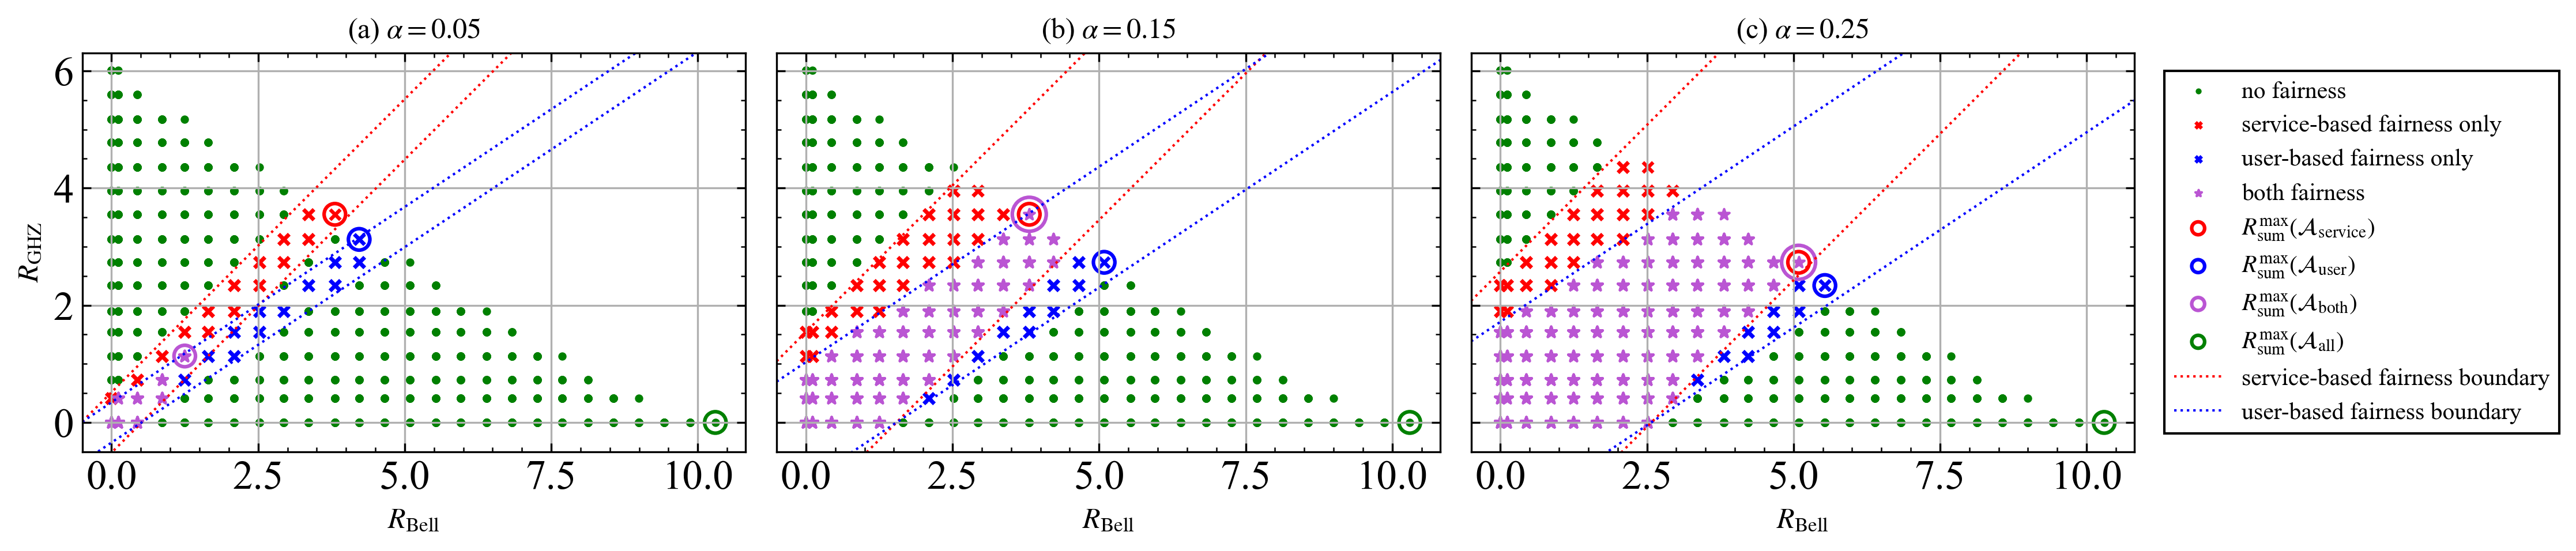

In [13]:
def main():
    alpha_list = [0.05, 0.15, 0.25]
    panel_labels = ["a", "b", "c"]

    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 6),
        dpi=300,
        sharex=True,
        sharey=True,
    )

    for ax, alpha, panel_label in zip(axes, alpha_list, panel_labels):
        plot_fairness_panel(ax, df, alpha, panel_label)

    axes[0].set_ylabel(r"$R_{\mathrm{GHZ}}$")

    handles_all = []
    labels_all = []
    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        handles_all.extend(handles)
        labels_all.extend(labels)

    unique = {}
    for handle, label in zip(handles_all, labels_all):
        if label not in unique and label != "_nolegend_":
            unique[label] = handle

    fig.legend(
        unique.values(),
        unique.keys(),
        loc="center left",
        bbox_to_anchor=(0.835, 0.5),
        markerscale=0.6,
        fontsize=10,
        frameon=True,
    )

    fig.tight_layout(rect=[0, 0, 0.84, 1])
    fig.savefig("QCNC_PLOT2.png", bbox_inches="tight", pad_inches=0.05)
    plt.show()


if __name__ == "__main__":
    main()